In [5]:
import pandas as pd

DATA_PATH = "cvetovik2.csv"
df = pd.read_csv(DATA_PATH)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df

,product_id,name,rating,rating_count,num_flowers,aroma,composition_flowers,target_price,bonus,city
0,5300,Букет из 51 розы микс 35-40 см (Кения) под атл...,5.0,8,51.0,яркий,роза,3280.0,164,Москва
1,3469,Букет из 51 красной розы 35-40 см (Кения) под ...,4.6,590,51.0,яркий,роза,3290.0,165,Москва
2,4657,Букет из 25 альстромерий нежный микс под ленту,5.0,171,25.0,без запаха,альстромерия,3820.0,191,Москва
3,3265,Букет из 101 розы яркий микс 35-40 см (Кения),5.0,812,101.0,яркий,роза,7140.0,357,Москва
4,3982,Букет из 25 розовых гвоздик в стильной упаковке,4.7,599,25.0,сладкий,гвоздика,3290.0,165,Москва
5,5643,Букет из 35 красных роз (Кения) 50 см под ленту,4.7,165,35.0,яркий,роза,4170.0,209,Москва
6,4007,Букет из 101 розы нежный микс 35-40 см (Россия...,4.8,753,101.0,классический,роза,7140.0,357,Москва
7,4989,Букет из 51 альстромерий микс под ленту,5.0,4,51.0,без запаха,альстромерия,6590.0,330,Москва
8,2937,Букет из 35 роз микс 35-40 см (Кения) под атла...,4.7,838,35.0,яркий,роза,3170.0,159,Москва
9,1881,Букет из 15 гербер стандарт микс в стильной уп...,4.5,536,15.0,свежий,гербера,3390.0,170,Москва


In [7]:
#сколько пропусков и в каких местах смотрим
rows_with_na = df[df.isna().any(axis=1)]
print("Количество строк с пропусками:", len(rows_with_na))
rows_with_na

Количество строк с пропусками: 81


,product_id,name,rating,rating_count,num_flowers,aroma,composition_flowers,target_price,bonus,city
135,4400,Букет цветов Струны души S,5.0,677,15.0,NaN,"роза, хризантема",9461.0,474,Москва
191,123,Сантини белая ромашка,5.0,751,NaN,сладкий,хризантема,251.0,13,Москва
192,78,Сантини микс,5.0,944,NaN,сладкий,хризантема,251.0,13,Москва
341,542,Букет из 15 матрикарий в стильной упаковке,4.5,331,15.0,NaN,ромашка,5240.0,262,Москва
343,5159,Букет цветов Летний сад,4.6,166,11.0,NaN,ромашка,4841.0,243,Москва
345,5160,Букет цветов Солнечный рай,4.9,197,25.0,NaN,ромашка,9965.0,499,Москва
346,5609,Букет из 11 матрикарий в стильной упаковке,4.8,188,11.0,NaN,ромашка,3738.0,187,Москва
348,5094,Букет цветов Летнее поле,4.5,147,10.0,NaN,"хризантема, ромашка",6048.0,303,Москва
350,2004,Букет из 35 матрикарий в дизайнерской упаковке,4.9,630,35.0,NaN,ромашка,10994.0,550,Москва
351,2156,Букет из 49 матрикарий в дизайнерской упаковке,4.7,492,49.0,NaN,ромашка,15131.0,757,Москва


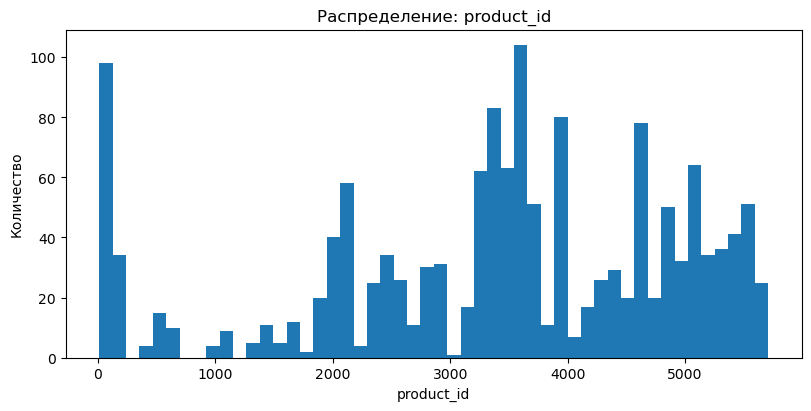

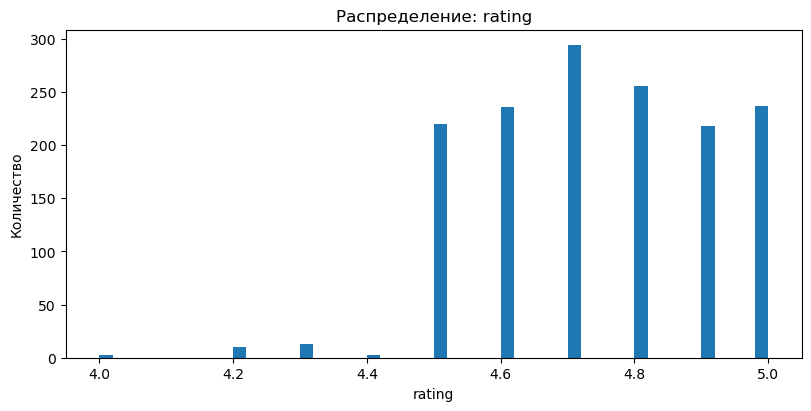

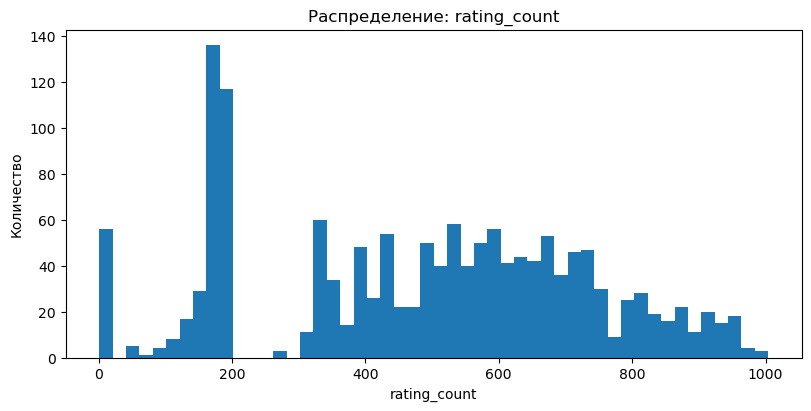

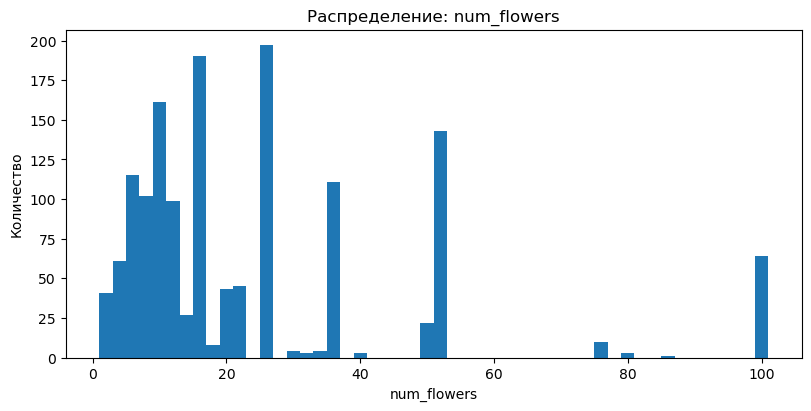

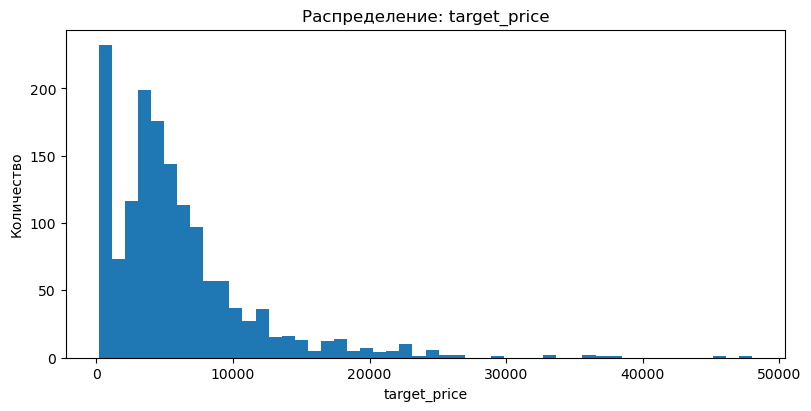

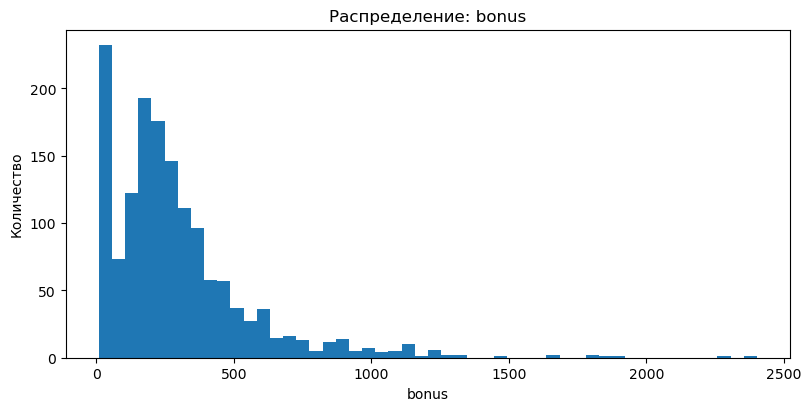

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество")
    plt.show()

In [11]:
#2 обработка данных
import pandas as pd
import numpy as np

df_clean = df.copy()

num_cols = [c for c in df_clean.columns if pd.api.types.is_numeric_dtype(df_clean[c])]
for c in num_cols:
    if df_clean[c].isna().any():
        median_value = df_clean[c].median()
        df_clean[c] = df_clean[c].fillna(median_value)
        print(f"Числовой столбец '{c}' заполнен медианой ({median_value:.2f})")

cat_cols = [c for c in df_clean.columns if df_clean[c].dtype == "object"]

for c in cat_cols:
    if df_clean[c].isna().any():
        top = df_clean[c].mode(dropna=True)
        fill_val = top.iloc[0] if not top.empty else "unknown"
        df_clean[c] = df_clean[c].fillna(fill_val)
        print(f"Категориальный столбец '{c}'  заполнен модой: {repr(fill_val)}")

def cap_outliers_iqr(series, k=1.5):
    """обрезаем выбросы по IQR"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return series.clip(lower=low, upper=high)

for c in num_cols:
    before_std = df_clean[c].std()
    df_clean[c] = cap_outliers_iqr(df_clean[c])
    after_std = df_clean[c].std()
    if not np.isclose(before_std, after_std):
        print(f"Выбросы обработаны в '{c}': std {before_std:.2f} -> {after_std:.2f}")

print("\nПроверка пропусков после обработки:")
print(df_clean.isna().sum())

df_clean.to_csv("cvetovik2_clean.csv", index=False)

Числовой столбец 'num_flowers' заполнен медианой (15.00)
Категориальный столбец 'aroma'  заполнен модой: 'без запаха'
Категориальный столбец 'composition_flowers'  заполнен модой: 'хризантема'
Выбросы обработаны в 'rating': std 0.18 -> 0.18
Выбросы обработаны в 'num_flowers': std 22.38 -> 15.23
Выбросы обработаны в 'target_price': std 5354.69 -> 4024.29
Выбросы обработаны в 'bonus': std 267.73 -> 201.32

Проверка пропусков после обработки:
product_id             0
name                   0
rating                 0
rating_count           0
num_flowers            0
aroma                  0
composition_flowers    0
target_price           0
bonus                  0
city                   0
dtype: int64


In [13]:
#2 в кат пер
df_clean = pd.read_csv("cvetovik2_clean.csv")
print("\nУникальные значения AROMA")
print(df_clean["aroma"].unique())

print("\nУникальные значения CITY")
print(df_clean["city"].unique())


Уникальные значения AROMA
['яркий' 'без запаха' 'сладкий' 'классический' 'свежий' 'фруктовый'
 'опьяняющий' 'медовый' 'травяной' 'лёгкий' 'пряный']

Уникальные значения CITY
['Москва' 'Санкт-Петербург' 'Псков' 'Краснодар' 'Казань']


In [15]:
# Категориальные в числовые 
import pandas as pd

df = pd.read_csv("cvetovik2_clean.csv")

aroma_vals = sorted(df["aroma"].astype(str).unique())
city_vals  = sorted(df["city"].astype(str).unique())

aroma_to_id = {name: i+1 for i, name in enumerate(aroma_vals)}
city_to_id  = {name: i+1 for i, name in enumerate(city_vals)}

df["aroma_id"] = df["aroma"].astype(str).map(aroma_to_id).astype(int)
df["city_id"]  = df["city"].astype(str).map(city_to_id).astype(int)

pd.DataFrame({"aroma": aroma_vals, "aroma_id": [aroma_to_id[a] for a in aroma_vals]}).to_csv(
    "aroma_mapping.csv", index=False
)
pd.DataFrame({"city": city_vals, "city_id": [city_to_id[c] for c in city_vals]}).to_csv(
    "city_mapping.csv", index=False
)
df.to_csv("cvetovik2_with_ids.csv", index=False)
print("Сохранено в: cvetovik2_with_ids.csv")
print("\nМаппинг AROMA:", aroma_to_id)
print("Маппинг CITY:", city_to_id)
df[["aroma", "aroma_id", "city", "city_id"]].head(10)

Сохранено в: cvetovik2_with_ids.csv

Маппинг AROMA: {'без запаха': 1, 'классический': 2, 'лёгкий': 3, 'медовый': 4, 'опьяняющий': 5, 'пряный': 6, 'свежий': 7, 'сладкий': 8, 'травяной': 9, 'фруктовый': 10, 'яркий': 11}
Маппинг CITY: {'Казань': 1, 'Краснодар': 2, 'Москва': 3, 'Псков': 4, 'Санкт-Петербург': 5}


,aroma,aroma_id,city,city_id
0,яркий,11,Москва,3
1,яркий,11,Москва,3
2,без запаха,1,Москва,3
3,яркий,11,Москва,3
4,сладкий,8,Москва,3
5,яркий,11,Москва,3
6,классический,2,Москва,3
7,без запаха,1,Москва,3
8,яркий,11,Москва,3
9,свежий,7,Москва,3


In [17]:
#маппим все. водно
import pandas as pd

DATA_PATH = "cvetovik2_with_ids.csv" 
AROMA_MAP_PATH = "aroma_mapping.csv"
CITY_MAP_PATH  = "city_mapping.csv"

OUT_WITH_IDS   = "cvetovik2_with_ids_mapped.csv"
OUT_NUMERIC    = "cvetovik2_with_ids_mapped_numeric_only_id.csv"

df = pd.read_csv(DATA_PATH)
aroma_map = pd.read_csv(AROMA_MAP_PATH)
city_map  = pd.read_csv(CITY_MAP_PATH)

def norm(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip()

if "aroma" in df.columns:
    df["aroma"] = norm(df["aroma"]).fillna("")
if "city" in df.columns:
    df["city"] = norm(df["city"]).fillna("")

if "aroma" in aroma_map.columns:
    aroma_map["aroma"] = norm(aroma_map["aroma"])
if "city" in city_map.columns:
    city_map["city"] = norm(city_map["city"])

if "aroma_id" in aroma_map.columns:
    aroma_map["aroma_id"] = aroma_map["aroma_id"].astype(int)
if "city_id" in city_map.columns:
    city_map["city_id"] = city_map["city_id"].astype(int)

df_mapped = df.copy()
for col in ["aroma_id", "city_id"]:
    if col in df_mapped.columns:
        df_mapped.drop(columns=[col], inplace=True)

df_mapped = df_mapped.merge(aroma_map[["aroma", "aroma_id"]], on="aroma", how="left")
df_mapped = df_mapped.merge(city_map[["city", "city_id"]], on="city", how="left")

missing_aroma = int(df_mapped["aroma_id"].isna().sum())
missing_city  = int(df_mapped["city_id"].isna().sum())

unknown_aromas = sorted(df_mapped.loc[df_mapped["aroma_id"].isna(), "aroma"].dropna().unique().tolist())
unknown_cities = sorted(df_mapped.loc[df_mapped["city_id"].isna(), "city"].dropna().unique().tolist())

df_mapped.to_csv(OUT_WITH_IDS, index=False)
print(f"\nSaved: {OUT_WITH_IDS}  (shape={df_mapped.shape})")

cols_to_drop = [c for c in ["aroma", "city"] if c in df_mapped.columns]
df_numeric = df_mapped.drop(columns=cols_to_drop)
df_numeric.to_csv(OUT_NUMERIC, index=False)
print(f"Saved: {OUT_NUMERIC}  (shape={df_numeric.shape})")

print("\nPreview (mapped):")
print(df_mapped.head(5))
print("\nPreview (numeric):")
print(df_numeric.head(5))


Saved: cvetovik2_with_ids_mapped.csv  (shape=(1490, 12))
Saved: cvetovik2_with_ids_mapped_numeric_only_id.csv  (shape=(1490, 10))

Preview (mapped):
   product_id                                               name  rating  \
0        5300  Букет из 51 розы микс 35-40 см (Кения) под атл...     5.0   
1        3469  Букет из 51 красной розы 35-40 см (Кения) под ...     4.6   
2        4657     Букет из 25 альстромерий нежный микс под ленту     5.0   
3        3265      Букет из 101 розы яркий микс 35-40 см (Кения)     5.0   
4        3982    Букет из 25 розовых гвоздик в стильной упаковке     4.7   

   rating_count  num_flowers       aroma composition_flowers  target_price  \
0             8         49.0       яркий                роза        3280.0   
1           590         49.0       яркий                роза        3290.0   
2           171         25.0  без запаха        альстромерия        3820.0   
3           812         49.0       яркий                роза        7140.0   
4  

In [19]:
# маппим переменную цветы в составе
import pandas as pd

SRC = "cvetovik2_with_ids_mapped_numeric_only_id.csv"
OUT_WITH_TEXT = "cvetovik2_with_comp_mapped.csv"
OUT_NUMERIC   = "cvetovik2_numeric_comp_id.csv"
COMP_MAP      = "composition_flowers_mapping.csv"

df = pd.read_csv(SRC)

comp_norm = df["composition_flowers"].astype("string").str.strip().fillna("")
unique_vals = sorted(comp_norm.unique().tolist())
comp_to_id = {name: i + 1 for i, name in enumerate(unique_vals)}

map_df = pd.DataFrame({"composition_flowers": unique_vals,
                       "composition_flowers_id": [comp_to_id[v] for v in unique_vals]})
map_df.to_csv(COMP_MAP, index=False)

df_with_text = df.copy()
df_with_text["composition_flowers"] = comp_norm
df_with_text["composition_flowers_id"] = df_with_text["composition_flowers"].map(comp_to_id).astype(int)

missing = int(df_with_text["composition_flowers_id"].isna().sum())

df_with_text.to_csv(OUT_WITH_TEXT, index=False)
df_numeric = df_with_text.drop(columns=["composition_flowers"])
df_numeric.to_csv(OUT_NUMERIC, index=False)

print(f"откуда взяли: {SRC}")
print(f"сохранено (текст + comp_id): {OUT_WITH_TEXT}")
print(f"Сохранено (только comp_id):  {OUT_NUMERIC}")
print(f"Таблица соответствий:        {COMP_MAP}")
print(f"Всего уникальных значений composition_flowers: {len(unique_vals)}")

print("\nPreview mapped (with text):")
print(df_with_text.head(5))
print("\nPreview numeric (no text):")
print(df_numeric.head(5))

откуда взяли: cvetovik2_with_ids_mapped_numeric_only_id.csv
сохранено (текст + comp_id): cvetovik2_with_comp_mapped.csv
Сохранено (только comp_id):  cvetovik2_numeric_comp_id.csv
Таблица соответствий:        composition_flowers_mapping.csv
Всего уникальных значений composition_flowers: 38

Preview mapped (with text):
   product_id                                               name  rating  \
0        5300  Букет из 51 розы микс 35-40 см (Кения) под атл...     5.0   
1        3469  Букет из 51 красной розы 35-40 см (Кения) под ...     4.6   
2        4657     Букет из 25 альстромерий нежный микс под ленту     5.0   
3        3265      Букет из 101 розы яркий микс 35-40 см (Кения)     5.0   
4        3982    Букет из 25 розовых гвоздик в стильной упаковке     4.7   

   rating_count  num_flowers composition_flowers  target_price  bonus  \
0             8         49.0                роза        3280.0    164   
1           590         49.0                роза        3290.0    165   
2    

In [58]:
#бейзлайн
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("cvetovik2_numeric_comp_id.csv")
target_col = "target_price"

num_cols = [
    c for c in df.columns
    if c != target_col
    and pd.api.types.is_numeric_dtype(df[c])
    and not c.lower().endswith("_id")
]
X = df[num_cols].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels = kmeans.fit_predict(X.values)

sil = silhouette_score(X.values, labels) if len(np.unique(labels)) >= 2 else float('nan')
print(f"[Naive KMeans(k=2)] silhouette = {sil:.3f}")


[Naive KMeans(k=2)] silhouette = 0.400


k_best = 2, pca_n = 2
 Silhouette=0.372
PCA explained variance ratio (sum): 0.432  | components: [0.229 0.203]


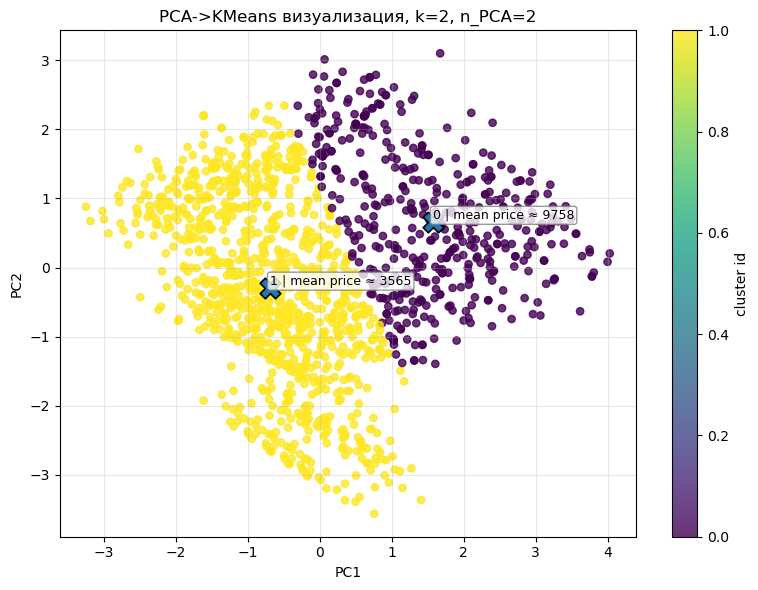

,cluster,train_size,mean_price_train
0,0,368,9757.629755
1,1,824,3564.537621


In [44]:
# === Полностью автономная ячейка PCA -> KMeans ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# ---- входные данные ----
CSV_PATH   = "cvetovik2_numeric_comp_id.csv"   # замени на свой файл, если другой
TARGET_COL = "target_price"                    # таргет-столбец (цена)

df = pd.read_csv(CSV_PATH)

# берём только числовые признаки, кроме таргета
feature_cols = [c for c in df.columns 
                if c != TARGET_COL and pd.api.types.is_numeric_dtype(df[c])]
X = df[feature_cols].copy()
y = df[TARGET_COL].to_numpy()

# train/val
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[feature_cols].to_numpy()
y_train = train_df[TARGET_COL].to_numpy()
X_val   = val_df[feature_cols].to_numpy()
y_val   = val_df[TARGET_COL].to_numpy()

# ---- гиперпараметры ----
k_best = 2
pca_n  = 2
print(f"k_best = {k_best}, pca_n = {pca_n}")

# ---- пайплайн: препроцессинг -> PCA -> KMeans ----
pipe_pca = Pipeline([
    ("prep", StandardScaler()),
    ("pca",  PCA(n_components=pca_n, random_state=42)),
    ("kmeans", KMeans(n_clusters=k_best, init="k-means++",
                      n_init=10, max_iter=300, random_state=42))
])

pipe_pca.fit(X_train)

# предсказания кластеров
clusters_train = pipe_pca.predict(X_train)
clusters_val   = pipe_pca.predict(X_val)

# маппинг "кластер -> средняя цена" по train
cluster_to_price = (pd.DataFrame({"cluster": clusters_train, "price": y_train})
                    .groupby("cluster")["price"].mean().to_dict())
global_med_train = float(np.nanmedian(y_train))
y_pred_val = np.array([cluster_to_price.get(c, global_med_train) for c in clusters_val])

# силуэт в PCA-пространстве
Z_train_pca = pipe_pca.named_steps["pca"].transform(
    pipe_pca.named_steps["prep"].transform(X_train)
)
sil = silhouette_score(Z_train_pca, clusters_train) if k_best < len(X_train) else np.nan

# объяснённая дисперсия PCA
evr = pipe_pca.named_steps["pca"].explained_variance_ratio_
print(f" Silhouette={sil:.3f}")
print(f"PCA explained variance ratio (sum): {evr.sum():.3f}  | components: {np.round(evr, 3)}")

# визуализация на train+val
X_all = pd.concat([train_df[feature_cols], val_df[feature_cols]], ignore_index=True)
y_all = np.concatenate([y_train, y_val])

coords_all = pipe_pca.named_steps["pca"].transform(
    pipe_pca.named_steps["prep"].transform(X_all.to_numpy())
)
clusters_all = pipe_pca.predict(X_all.to_numpy())

centers_pca = pipe_pca.named_steps["kmeans"].cluster_centers_  # уже в PCA-пространстве
center_labels = {c: f"{c} | mean price ≈ {cluster_to_price.get(c, global_med_train):.0f}"
                 for c in range(k_best)}

plt.figure(figsize=(8, 6))
sc = plt.scatter(coords_all[:, 0], coords_all[:, 1], c=clusters_all, s=28, alpha=0.8)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=220, edgecolor="black", linewidths=1.2)
for cid, (cx, cy) in enumerate(centers_pca):
    plt.text(cx, cy, center_labels[cid], fontsize=9,
             ha="left", va="bottom", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8))

plt.title(f"PCA->KMeans визуализация, k={k_best}, n_PCA={pca_n}")
plt.xlabel("PC1"); plt.ylabel("PC2")
cbar = plt.colorbar(sc); cbar.set_label("cluster id")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# сводка по размерам и средним ценам кластеров (train)
sizes = pd.Series(clusters_train).value_counts().sort_index()
summary = pd.DataFrame({
    "cluster": list(range(k_best)),
    "train_size": [int(sizes.get(i, 0)) for i in range(k_best)],
    "mean_price_train": [float(cluster_to_price.get(i, global_med_train)) for i in range(k_best)]
})
display(summary)


In [54]:
#самописная
import numpy as np
from numpy.random import RandomState
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

class MyKMeans(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=3, init="k-means++", n_init=10, max_iter=300,
                 tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.init = init
        self.n_init = n_init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _prepare_X(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be 2D array-like")
        if self.n_clusters > X.shape[0]:
            raise ValueError(f"n_clusters({self.n_clusters}) > n_samples({X.shape[0]})")
        return X

    def _dist_sq(self, X, C):
        # ||x-c||^2 = ||x||^2 + ||c||^2 - 2 x·c
        x2 = np.sum(X * X, axis=1, keepdims=True)
        c2 = np.sum(C * C, axis=1)
        D = x2 + c2 - 2.0 * (X @ C.T)
        np.maximum(D, 0.0, out=D)
        return D

    def _init_random(self, X, rng):
        idx = rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[idx].copy()

    def _init_kpp(self, X, rng):
        n, d = X.shape
        C = np.empty((self.n_clusters, d), dtype=float)
        C[0] = X[rng.randint(n)]
        closest = self._dist_sq(X, C[0:1]).ravel()
        for i in range(1, self.n_clusters):
            np.maximum(closest, 0.0, out=closest)
            s = closest.sum()
            if not np.isfinite(s) or s <= 0.0:
                idx = rng.randint(n)
            else:
                probs = closest / s
                idx = rng.choice(n, p=probs)
            C[i] = X[idx]
            closest = np.minimum(closest, self._dist_sq(X, C[i:i+1]).ravel())
        return C

    def _fit_once(self, X, rng):
        C = self._init_kpp(X, rng) if self.init == "k-means++" else self._init_random(X, rng)
        for _ in range(self.max_iter):
            D = self._dist_sq(X, C)
            labels = D.argmin(axis=1)

            moved = 0.0
            C_new = C.copy()
            for j in range(self.n_clusters):
                m = (labels == j)
                if np.any(m):
                    c_new = X[m].mean(axis=0)
                else:
                    c_new = X[rng.randint(X.shape[0])]
                moved = max(moved, float(np.linalg.norm(c_new - C_new[j])))
                C_new[j] = c_new

            C = C_new
            if moved <= self.tol:
                break

        D = self._dist_sq(X, C)
        labels = D.argmin(axis=1)
        inertia = float(np.take_along_axis(D, labels[:, None], axis=1).sum())
        return C, labels, inertia

    def fit(self, X, y=None):
        X = self._prepare_X(X)
        self.n_features_in_ = X.shape[1]
        rng_master = RandomState(self.random_state)

        best_inertia = np.inf
        best_C = None
        best_labels = None

        for _ in range(int(self.n_init)):
            rng = RandomState(rng_master.randint(0, 10**9))
            C, labels, inertia = self._fit_once(X, rng)
            if inertia < best_inertia:
                best_inertia, best_C, best_labels = inertia, C, labels

        self.cluster_centers_ = best_C
        self.labels_ = best_labels
        self.inertia_ = float(best_inertia)
        return self

    def predict(self, X):
        if not hasattr(self, "cluster_centers_"):
            raise RuntimeError("Model is not fitted yet. Call fit(X) first.")
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError("X must be 2D array-like")
        D = self._dist_sq(X, self.cluster_centers_)
        return D.argmin(axis=1)

def silhouette_in_pca_space(pipeline, X):
    Z = pipeline.named_steps["pca"].transform(
        pipeline.named_steps["prep"].transform(X)
    )
    labels = pipeline.predict(X)
    return silhouette_score(Z, labels) if len(np.unique(labels)) >= 2 else np.nan

pca_n  = 2
k_best = 2

PREP = StandardScaler()       

pipe_custom = Pipeline([
    ("prep", PREP),
    ("pca",  PCA(n_components=pca_n, random_state=42)),
    ("myk",  MyKMeans(n_clusters=k_best, init="k-means++",
                      n_init=10, max_iter=300, tol=1e-4, random_state=42))
])
pipe_custom.fit(X_train)

sil_tr = silhouette_in_pca_space(pipe_custom, X_train)
sil_vl = silhouette_in_pca_space(pipe_custom, X_val)
print(f"Silhouette (train) = {sil_tr:.3f} | Silhouette (val) = {sil_vl:.3f}")


Silhouette (train) = 0.372 | Silhouette (val) = 0.338


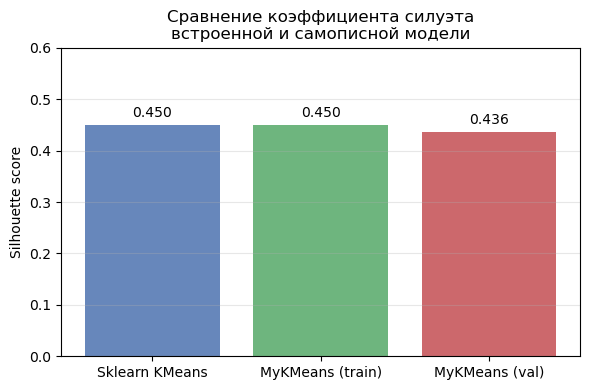

In [56]:
#сравнение
import matplotlib.pyplot as plt
import numpy as np

sil_builtin = 0.372
sil_myk_train = 0.372
sil_myk_val = 0.338

models = ["Sklearn KMeans", "MyKMeans (train)", "MyKMeans (val)"]
scores = [sil_builtin, sil_myk_train, sil_myk_val]
colors = ["#4C72B0", "#55A868", "#C44E52"]

plt.figure(figsize=(6,4))
bars = plt.bar(models, scores, color=colors, alpha=0.85)
plt.title("Сравнение коэффициента силуэта\nвстроенной и самописной модели", fontsize=12)
plt.ylabel("Silhouette score")
plt.ylim(0, 0.6)
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", 
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()
